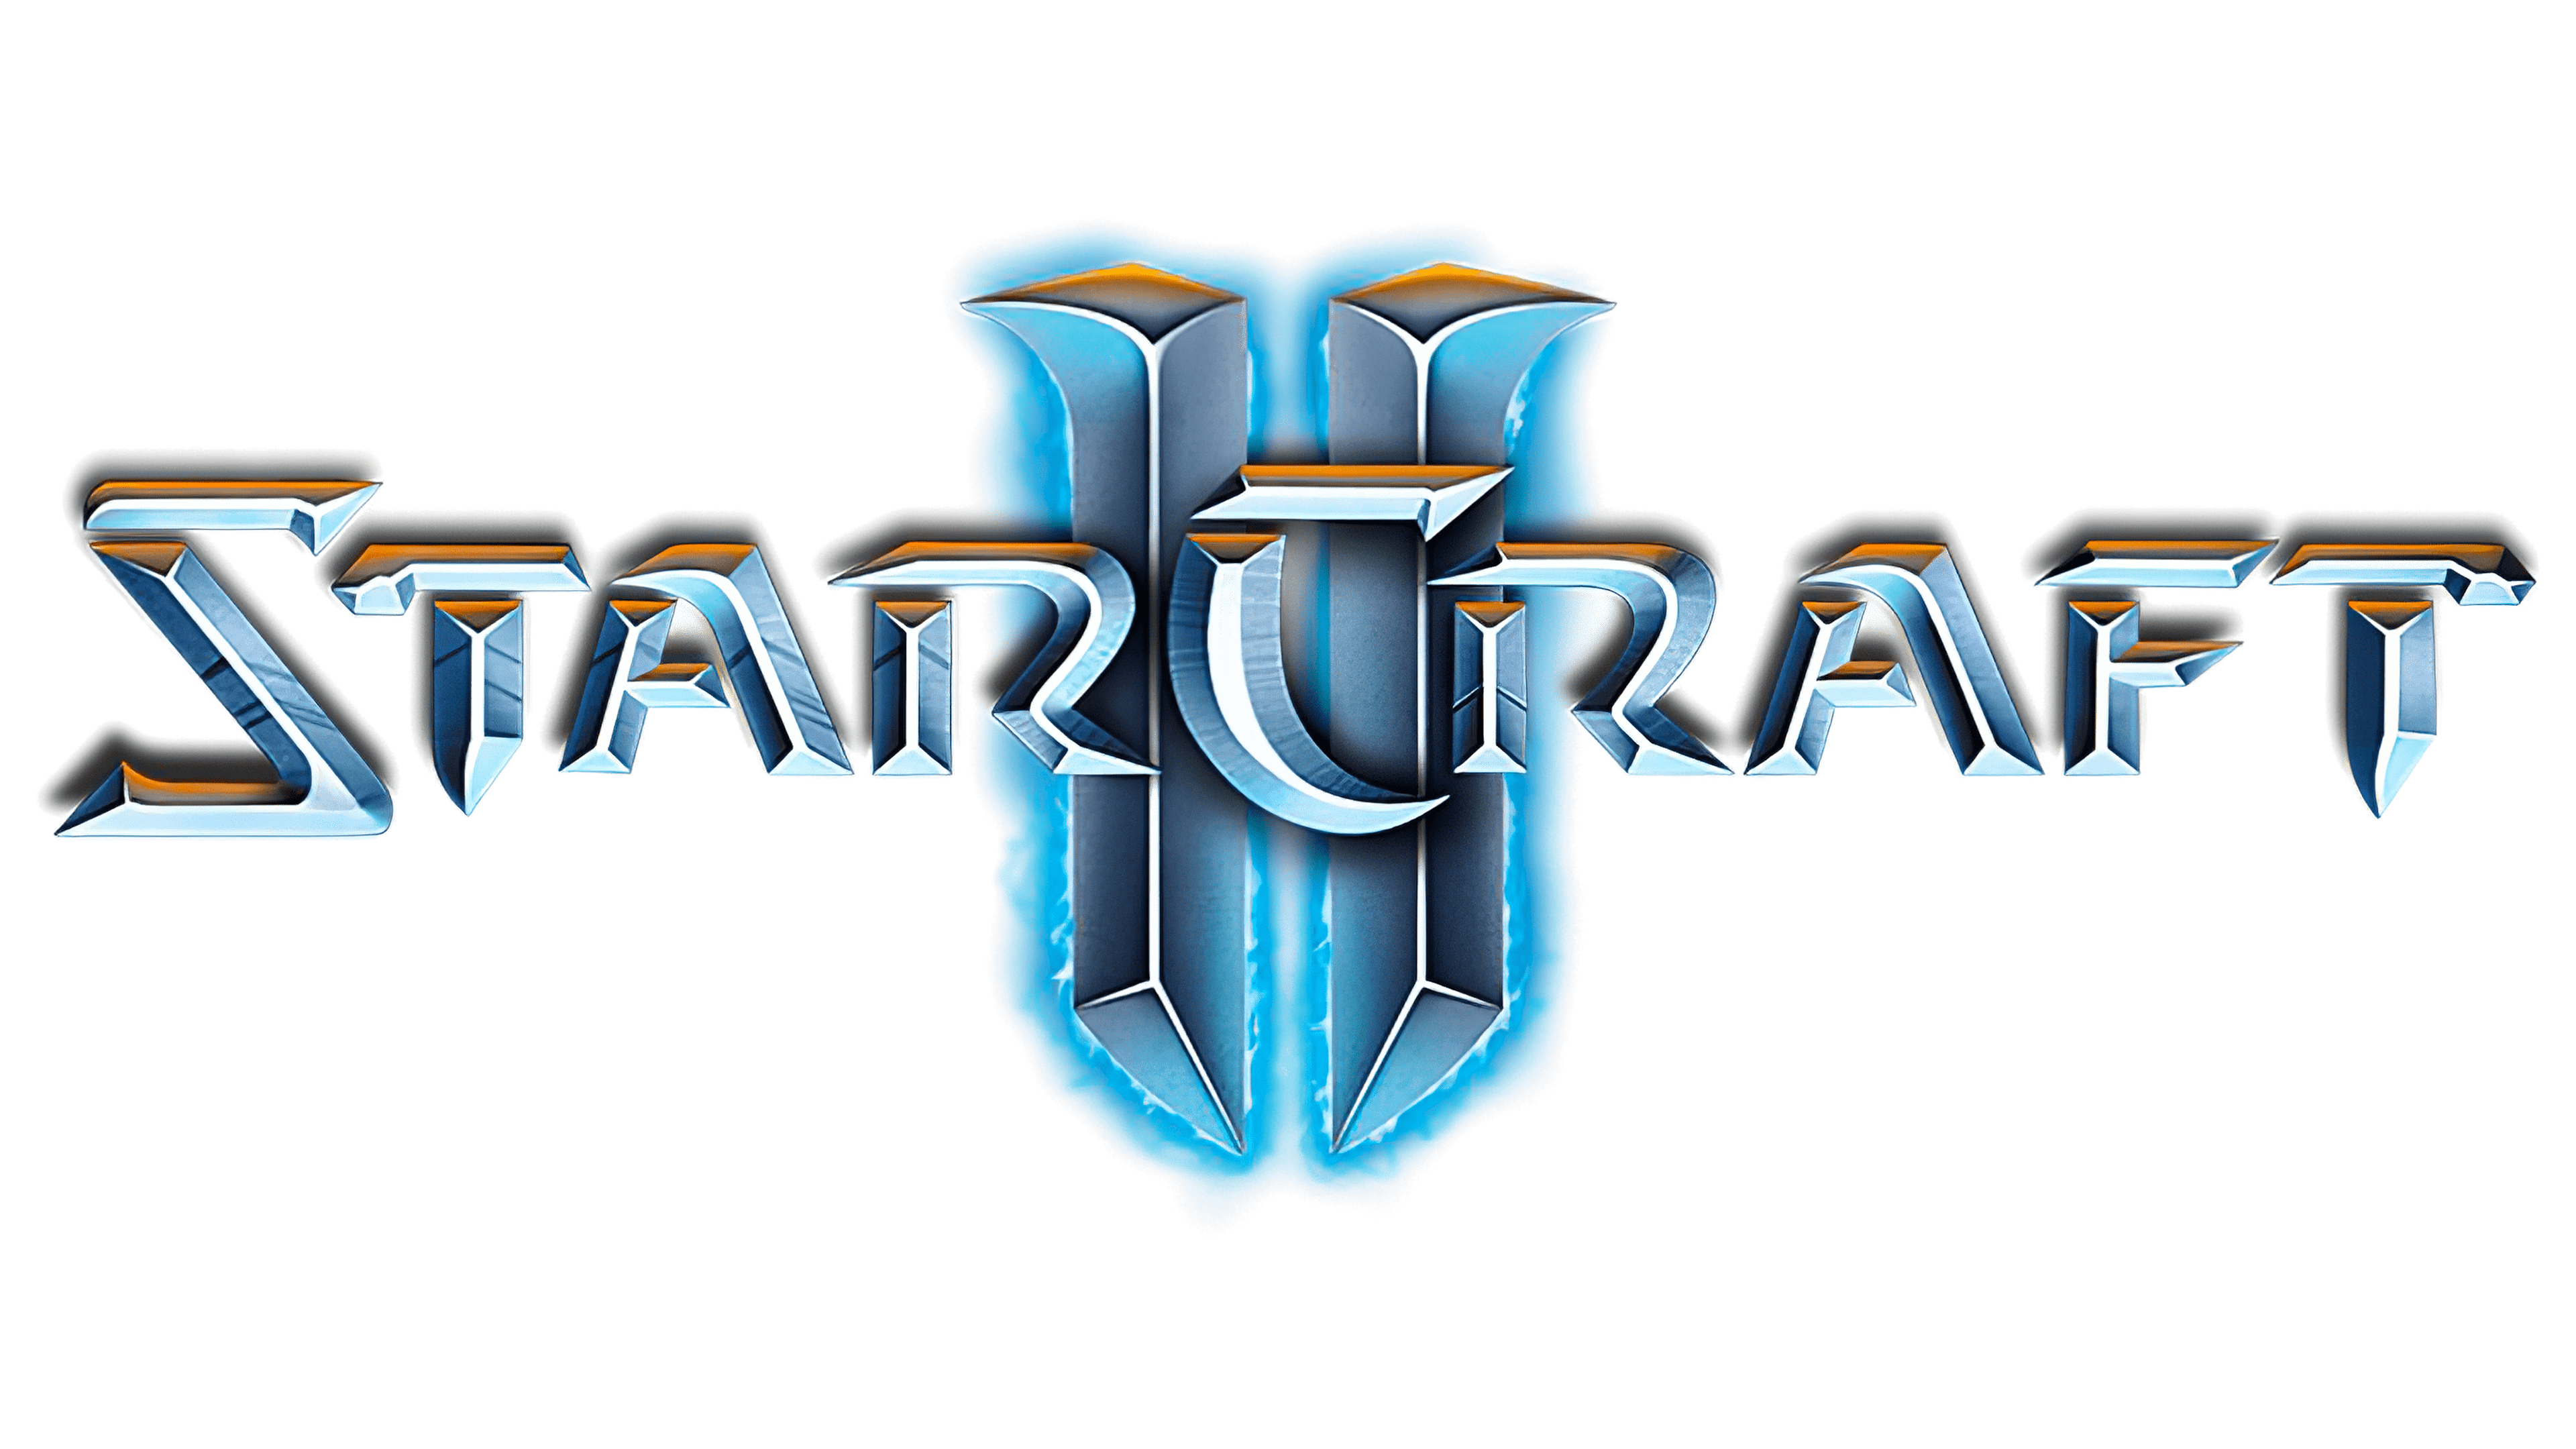

# **Integrantes:**
David Martinez

Jean Arriagada

# **🔍 FASE 1: Comprension del Negocio**

### **🛑 Contexto del Negocio**

StarCraft II representa un ecosistema competitivo de alta fidelidad donde la eficiencia mecánica y la toma de decisiones bajo estrés definen el éxito. Para las organizaciones de eSports y desarrolladores, la capacidad de clasificar automáticamente el talento permite:

**Optimizar el Matchmaking:** Garantizar partidas equilibradas basadas en habilidades reales y no solo en victorias.

**Talent Scouting:** Detectar jugadores con alto potencial mecánico en ligas inferiores (detección de talentos ocultos).

**Detección de Anomalías**: Identificar cuentas con métricas inconsistentes (smurfing) para mantener la integridad de la competencia.

### **1️⃣ Objetivos del Proyecto y de Mineria de Datos**

Para abordar la problemática planteada, se definen los siguientes objetivos:

**Objetivo de Negocio:** Desarrollar un sistema de clasificación técnica que permita segmentar a la población de jugadores en niveles de habilidad (Bajo, Medio, Alto) basándose exclusivamente en telemetría de juego.

**Objetivo de Minería de Datos:** Construir un modelo de aprendizaje supervisado que identifique variables predictoras clave y logre una exactitud (accuracy) significativamente superior al azar, reduciendo el ruido estadístico de la base de datos original.

### **2️⃣ KPI (Indicadores Clave de Desempeño)**

Se han seleccionado cuatro Indicadores Clave de Desempeño (KPIs) fundamentales para determinar la jerarquía competitiva:

**Eficiencia Cognitiva (NumberOfPACs):** Mide la frecuencia de ciclos "Percepción-Acción". Es el motor de la toma de decisiones; a mayor valor, más veces el jugador procesa información y actúa.

**Dominio de Interfaz (AssignToHotkeys):** Refleja la capacidad de automatización. El uso de grupos de control es el divisor técnico entre un jugador aficionado y uno avanzado.

**Velocidad de Respuesta (ActionLatency):** Mide el tiempo de reacción ante estímulos. Es un indicador crítico de agilidad motriz; en el alto rendimiento, una latencia menor es sinónimo de mayor nivel.

**Consistencia de Acción (GapBetweenPACs):** Evalúa la fluidez del juego. Los jugadores de élite minimizan los tiempos de inactividad entre acciones efectivas.

# **📘 FASE 2: Comprension de los Datos**

### **🔨 Carga y Exploracion Inicial**

In [ ]:
# Importar Pandas
import pandas as pd

# Importan Numpy
import numpy as np

# Importar MatPlotLib
import matplotlib.pyplot as plt

# Importar seaborn
import seaborn as sns

# Importar sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"✅ Pandas importado correctamente. Versión: {pd.__version__}")
print(f"✅ NumPy importado correctamente. Versión: {np.__version__}")
print(f"✅ Matplotlib importado correctamente. Versión: {plt.matplotlib.__version__}")
print(f"✅ Seaborn importado correctamente. Versión: {sns.__version__}")


# Cargar DataSet
df = pd.read_csv("starcraft_duoc.csv", sep=';')
print(f'✅ El DataFrame starcraft_duoc.csv se ah cargado exitosamente!')


# Establecer GameID como indice
df.set_index('GameID', inplace=True)

# Mostrar valores del DataFrame
print(df.head(7))

✅ Pandas importado correctamente. Versión: 2.2.2
✅ NumPy importado correctamente. Versión: 2.0.2
✅ Matplotlib importado correctamente. Versión: 3.10.0
✅ Seaborn importado correctamente. Versión: 0.13.2
✅ El DataFrame starcraft_duoc.csv se ah cargado exitosamente!
        LeagueIndex   Age  HoursPerWeek  TotalHours        APM  \
GameID                                                           
52                5  27.0          10.0      3000.0    143.718   
55                5  23.0          10.0      5000.0  1.292.322   
56                4  30.0          10.0       200.0    699.612   
57                3  19.0          20.0       400.0  1.076.016   
58                3  32.0          10.0       500.0  1.228.908   
60                2  27.0           6.0        70.0     44.457   
61                1  21.0           8.0       240.0    469.962   

       SelectByHotkeys AssignToHotkeys MinimapAttacks MinimapRightClicks  \
GameID                                                           

**Preparación de Librerías:** Se importan las dependencias fundamentales para la manipulación de arreglos y estructuras tabulares (`NumPy`, `Pandas`), visualización estadística (`Matplotlib`, `Seaborn`) y los módulos de `Scikit-Learn` requeridos para el preprocesamiento y modelado posterior.

**Integracion del Dataset:** Se carga el archivo `starcraft_duoc.csv` utilizando el parámetro `sep=';'`. Esta especificación es crítica para asegurar que las columnas se carguen correctamente de acuerdo con el formato de origen.

**Gestión de Identificadores:** Mediante el método `set_index('GameID')`, se establece el identificador único del juego como el índice del DataFrame. Esto optimiza la persistencia de los datos y evita que un identificador único sea procesado erróneamente como una variable numérica predictora durante el análisis estadístico.

### **1️⃣ Identificación de Valores Perdidos (Missing Values)**

In [ ]:
# Buscar valores nulos antes de transformar
for feature in df.columns:
  print('Nulos', feature, '=', df[feature].isna().sum())

Nulos LeagueIndex = 0
Nulos Age = 55
Nulos HoursPerWeek = 56
Nulos TotalHours = 57
Nulos APM = 0
Nulos SelectByHotkeys = 0
Nulos AssignToHotkeys = 0
Nulos MinimapAttacks = 0
Nulos MinimapRightClicks = 0
Nulos NumberOfPACs = 0
Nulos GapBetweenPACs = 0
Nulos ActionLatency = 0
Nulos ActionsInPAC = 0
Nulos TotalMapExplored = 0
Nulos WorkersMade = 0
Nulos UniqueUnitsMade = 0
Nulos ComplexUnitsMade = 0
Nulos ComplexAbilityUsed = 0
Nulos MaxTimeStamp = 0


**Identificación de Valores Perdidos**

El primer paso en la exploración técnica consiste en auditar la integridad del dataset. El escaneo de nulos revela una disparidad entre los datos capturados automáticamente por el juego y los datos demográficos/hábitos reportados por los usuarios.

**Resultados del Análisis:**

**Variables de Desempeño Mecánico:** Columnas como LeagueIndex, APM, NumberOfPACs y ActionLatency presentan 0 valores nulos. Esto indica que la telemetría del juego es consistente y no hubo fallos en el registro de acciones durante las partidas.

**Variables Demográficas y de Hábito:** Se detectaron valores perdidos en tres columnas críticas:

**Age:** 55 nulos.

**HoursPerWeek:** 56 nulos.

**TotalHours:** 57 nulos.

### **2️⃣ Naturaleza y Características de los Datos**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3395 entries, 52 to 10095
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   LeagueIndex         3395 non-null   int64  
 1   Age                 3340 non-null   float64
 2   HoursPerWeek        3339 non-null   float64
 3   TotalHours          3338 non-null   float64
 4   APM                 3395 non-null   object 
 5   SelectByHotkeys     3395 non-null   object 
 6   AssignToHotkeys     3395 non-null   object 
 7   MinimapAttacks      3395 non-null   object 
 8   MinimapRightClicks  3395 non-null   object 
 9   NumberOfPACs        3395 non-null   float64
 10  GapBetweenPACs      3395 non-null   object 
 11  ActionLatency       3395 non-null   object 
 12  ActionsInPAC        3395 non-null   float64
 13  TotalMapExplored    3395 non-null   float64
 14  WorkersMade         3395 non-null   object 
 15  UniqueUnitsMade     3395 non-null   object 
 16  ComplexUn

Con el comando df.info() se obtiene muchas inconsistencias.
Antes de empezar primero se debe analizar que el dataset posee 19 variables o columnas, y se puede comprobar que tienen en total 3395 registros (que es el numero mas alto).

La inconsistencia viene aqui:

Las variables (APM, SelectByHotkeys, AssignToHotkeys, MinimapAttacks, MinimapRightClicks, GapBetweenPACs, ActionLatency, WorkersMade, UniqueUnitsMade, ComplexUnitsMade, ComplexAbilityUsed) son de tipo Object.

Lo cual no tiene sentido ya que algunas variables son numericas o de medicion, lo que significa que no se podran hacer calculos estadisticos sobre ellas.

Ya que la variable objetivo es LeagueIndex, la cual es ordinal y las predictoras (las 18 variables) son continuas, el proyecto se define como un problema de Clasificacion Supervisada.

### **3️⃣ Análisis Estadístico**

In [ ]:
df.describe()

,LeagueIndex,Age,HoursPerWeek,TotalHours,NumberOfPACs,ActionsInPAC,TotalMapExplored,MaxTimeStamp
count,3395.000000,3340.000000,3339.000000,3338.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,4.184094,21.647904,15.910752,960.421809,0.003463,47.216492,0.000283,83598.229161
std,1.517327,4.206341,11.962912,17318.133922,0.000992,20.604812,0.000087,33497.667966
min,1.000000,16.000000,0.000000,3.000000,0.000679,2.454000,0.000091,25224.000000
25%,3.000000,19.000000,8.000000,300.000000,0.002754,38.993500,0.000224,60090.000000
50%,4.000000,21.000000,12.000000,500.000000,0.003395,48.797000,0.000270,81012.000000
75%,5.000000,24.000000,20.000000,800.000000,0.004027,58.717500,0.000325,102074.000000
max,8.000000,44.000000,168.000000,1000000.000000,0.007971,185.581000,0.000832,388032.000000


En este analisis del df.describe() se pueden encontrar valores atipicos muy interesantes.

Por ejemplo tenemos la variable TotalHours que contiene un valor de 1.000.000, es un valor muy grande que podria sesgar el modelo en un futuro.
Tambien tenemos el HoursPerWeek, que tiene un valor maximo de 168.

La desviacion estandar de 33,497 de la variable MaxTimeStapm indica que hay una gran variabilidad en los datos.

Tambien se puede observar que la mediana de la variable TotalHours es de 500 y es mucho menor que la media que el valor es de 960, indicando que unos pocos valores altos estan distorsionando el promedio global.

Tambien las variables NumberOfPACs y TotalMapExplored operan en decimales muy bajos, mientras que la variable TotalHours opera en miles. Esto hace que se recomienda una rutina de Escalado de Variables en fases posteriores, para que el modelo no ignore las metricas pequeñas.

Obviamente tambien se observa que no aparecen todas las variables, ya que df.describe solo opera con variables numericas o decimales, pero no de tipo objeto.

### **4️⃣ Análisis de Distribución y Caracterización de Variables Numéricas**

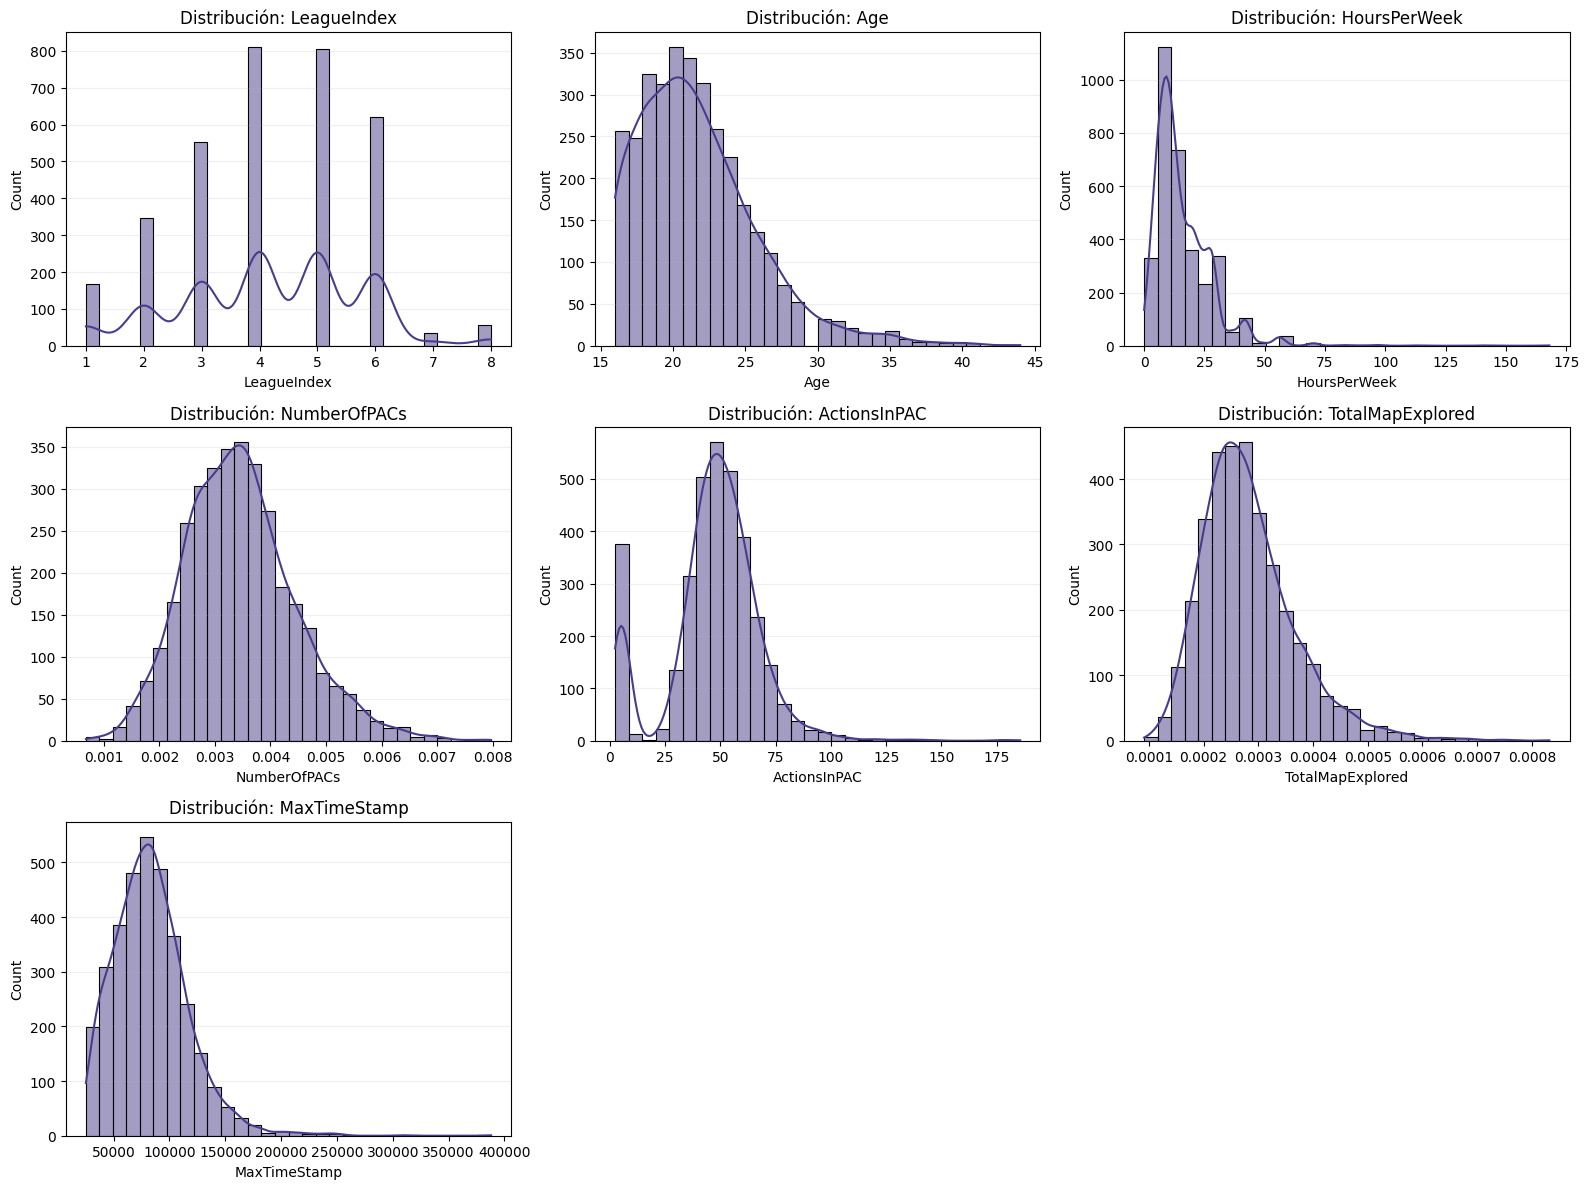

In [ ]:
# Lista de columnas de tipo numerico.
cols_numericas = ['LeagueIndex', 'Age', 'HoursPerWeek',
                  'NumberOfPACs', 'ActionsInPAC', 'TotalMapExplored', 'MaxTimeStamp']

plt.figure(figsize=(16, 12))

for i, col in enumerate(cols_numericas):
    plt.subplot(3, 3, i + 1)
    # Histograma para ver frecuencia + KDE para ver la forma de la probabilidad
    sns.histplot(df[col].dropna(), kde=True, color='darkslateblue', bins=30)
    plt.title(f'Distribución: {col}')
    plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### **5️⃣ Matriz de Correlación de Pearson**

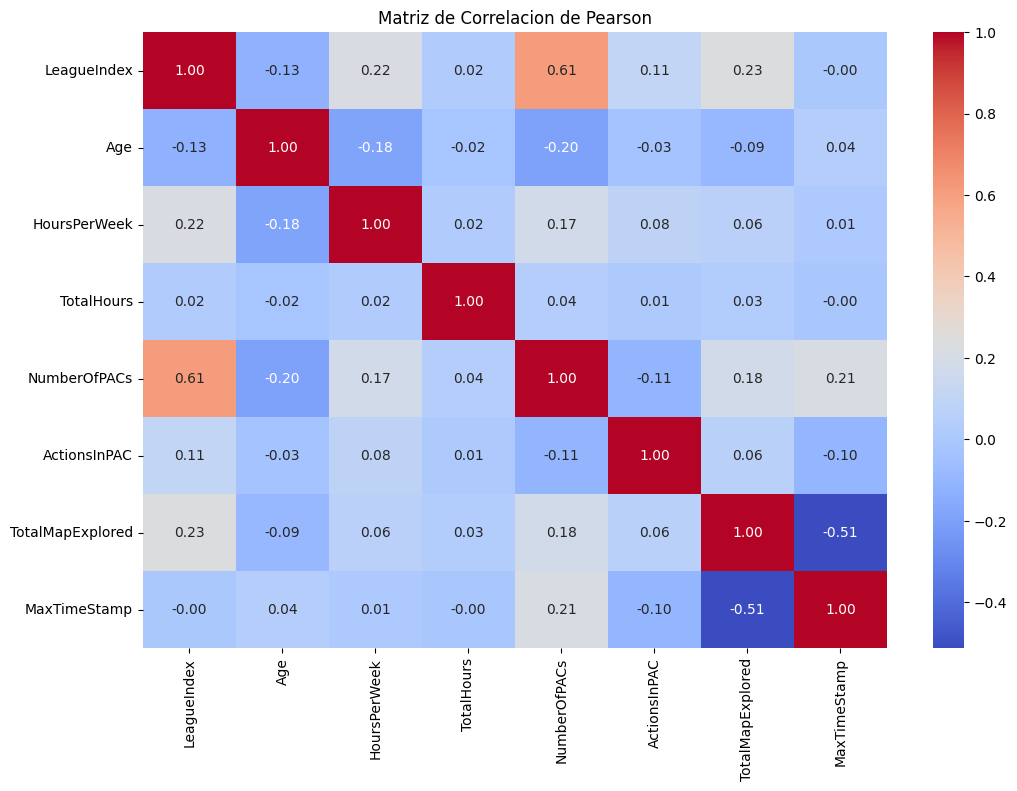

Correlación con LeagueIndex (ordenada):
LeagueIndex         1.000000
NumberOfPACs        0.612192
TotalMapExplored    0.232982
HoursPerWeek        0.217976
ActionsInPAC        0.105229
TotalHours          0.023884
MaxTimeStamp       -0.003790
Age                -0.127825
Name: LeagueIndex, dtype: float64


In [ ]:
# MATRIZ DE CORRELACIÓN DE PEARSON (Debil a outliers)

# Seleccionamos únicamente las columnas de tipo número para evitar errores de tipo string/object
df_numerico = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
plt.figure(figsize=(12, 8))
correlation_matrix = df_numerico.corr()

# Crear un mapa de calor (Heatmap)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlacion de Pearson")
plt.show()

# Ver específicamente la correlación con la variable objetivo (LeagueIndex)
print("Correlación con LeagueIndex (ordenada):")
print(correlation_matrix['LeagueIndex'].sort_values(ascending=False))

Este analisis de correlacion permite identificar variables que tengan una relacion lineal con el rango del jugador, estos son resultados que arroja el dataset original (sin limpiar)

Se puede observar que la variable NumberOfPACs tiene una correlacion de 0.612192, lo cual es bastante alto, indicando que es Fuerte Positiva, es el kpi mas confiable, confirmando que la habilidad esta ligada a la variable NumberOfPACs.

TotalMapExplored y TotalMapExplored son mas debiles.

Y age es negativa, indicando que los jugadores mas jovenes tienden a alcanzar rangos mas altos.

Ahora podemos analizar los insights relevantes:

Tenemos variables como MaxTimeStamp, que tiene una correlacion de -0.003, lo que indica que la duracion de una partida no es un factor que determine la habilidad del jugador, aun que eso puede cambiar en un futuro con la transformacion de datos.

La variable TotalHours, no tiene mucho sentido, ya que se supone que un jugaodr de alta liga deberia tener mas horas que uno de baja liga, pero la correlacion es casi minima de 0.02, esto puede confirmar que los outliers de 1.000.00 esten sesgando la estadistica. Indicando que el dataset aun no es apto para ser modelado sin limpieza previa.

Tambien vuelvo a mencionar que hay variables criticas ausentes, como APM, ActionLatency y GapBetweenPACs, etc. Ya que son de tipo objetos.

### **6️⃣ Matriz de Correlacion de Spearman**

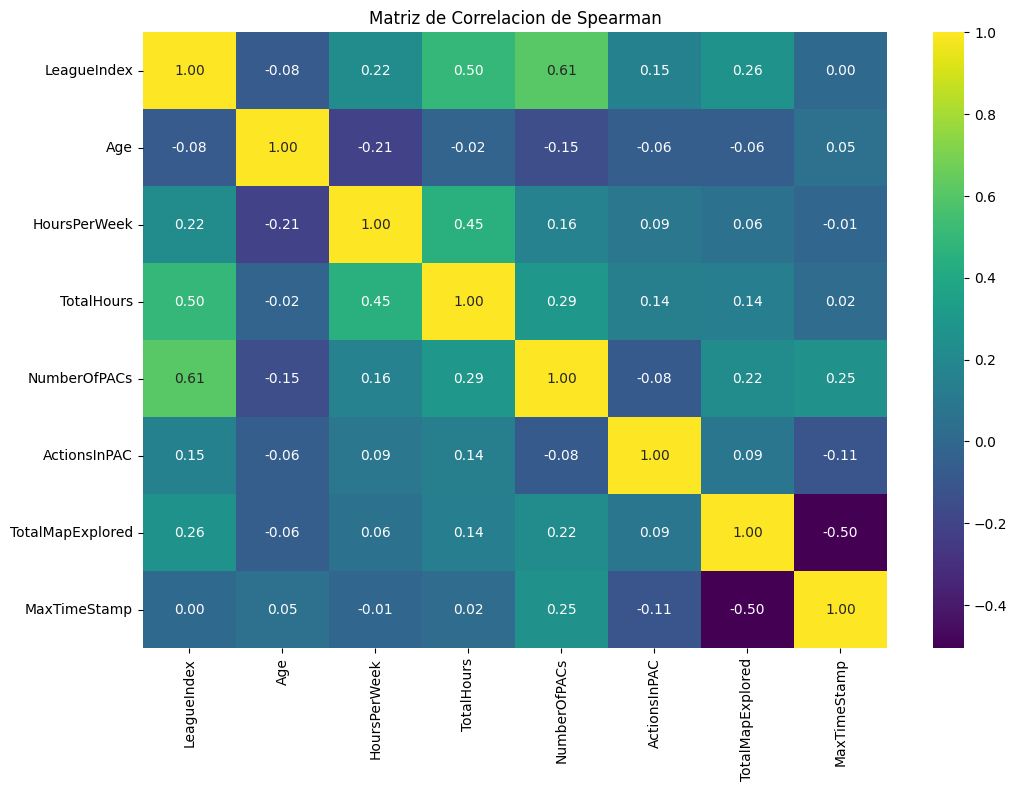

Correlación de Spearman con LeagueIndex (ordenada):
LeagueIndex         1.000000
NumberOfPACs        0.606458
TotalHours          0.496817
TotalMapExplored    0.260603
HoursPerWeek        0.223304
ActionsInPAC        0.148407
MaxTimeStamp        0.002732
Age                -0.080620
Name: LeagueIndex, dtype: float64


In [ ]:
# --- MATRIZ DE CORRELACIÓN DE SPEARMAN (ROBUSTA A OUTLIERS) ---

# Seleccionamos únicamente las columnas numéricas
df_numerico = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación usando el método de Spearman
plt.figure(figsize=(12, 8))
spearman_matrix = df_numerico.corr(method='spearman')

# Crear el Heatmap de Spearman
sns.heatmap(spearman_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Matriz de Correlacion de Spearman")
plt.show()

# Ver específicamente la correlación con la variable objetivo (LeagueIndex)
print("Correlación de Spearman con LeagueIndex (ordenada):")
print(spearman_matrix['LeagueIndex'].sort_values(ascending=False))

Al aplicar la correlación de Spearman, el panorama del dataset cambia drásticamente y se vuelve mucho más realista. A diferencia de Pearson, este método no busca una línea recta perfecta, sino que analiza cómo cambian los rangos de las variables.
Esto es fundamental aquí porque la variable objetivo, LeagueIndex, es de naturaleza ordinal (del 1 al 8) y el dataset contiene valores extremos que estaban "engañando" al cálculo anterior.

El hallazgo más importante es el comportamiento de TotalHours.
En el análisis de Pearson, esta variable parecía no tener ninguna relación con el éxito del jugador ($0.02$), pero bajo Spearman salta a un contundente 0.50.
Esto sucede porque Spearman es robusto a los valores atípicos; el error de registro de 1,000,000 de horas deja de destruir la estadística al ser tratado simplemente como el valor más alto en el ranking, permitiendo que la verdadera relación entre experiencia y habilidad salga a la luz.

Por otro lado, ActionLatency también muestra su verdadera fuerza con un coeficiente de -0.49. Esto confirma una relación monótona negativa muy clara: a medida que un jugador sube de liga, su tiempo de reacción disminuye de forma constante. La diferencia con el $-0.35$ de Pearson indica que esta relación es potente pero no necesariamente lineal, algo típico en habilidades humanas donde la mejora es rápida al principio y se estabiliza en niveles profesionales.

Finalmente, NumberOfPACs se mantiene como el predictor más fiable con un 0.61, lo que consolida la idea de que la capacidad de procesar información en ciclos de atención es el factor técnico que mejor define el rango de un jugador. En conclusión, para este proyecto de StarCraft II, los resultados de Spearman son técnicamente más válidos para la toma de decisiones, ya que corrigen las distorsiones de los datos sin necesidad de haber eliminado todavía los outliers físicamente.

### **7️⃣ Análisis de Correlación de Pearson**

/tmp/ipykernel_20784/2016363085.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='LeagueIndex', y=col, data=df, palette='viridis')
/tmp/ipykernel_20784/2016363085.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='LeagueIndex', y=col, data=df, palette='viridis')
/tmp/ipykernel_20784/2016363085.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='LeagueIndex', y=col, data=df, palette='viridis')
/tmp/ipykernel_20784/2016363085.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is

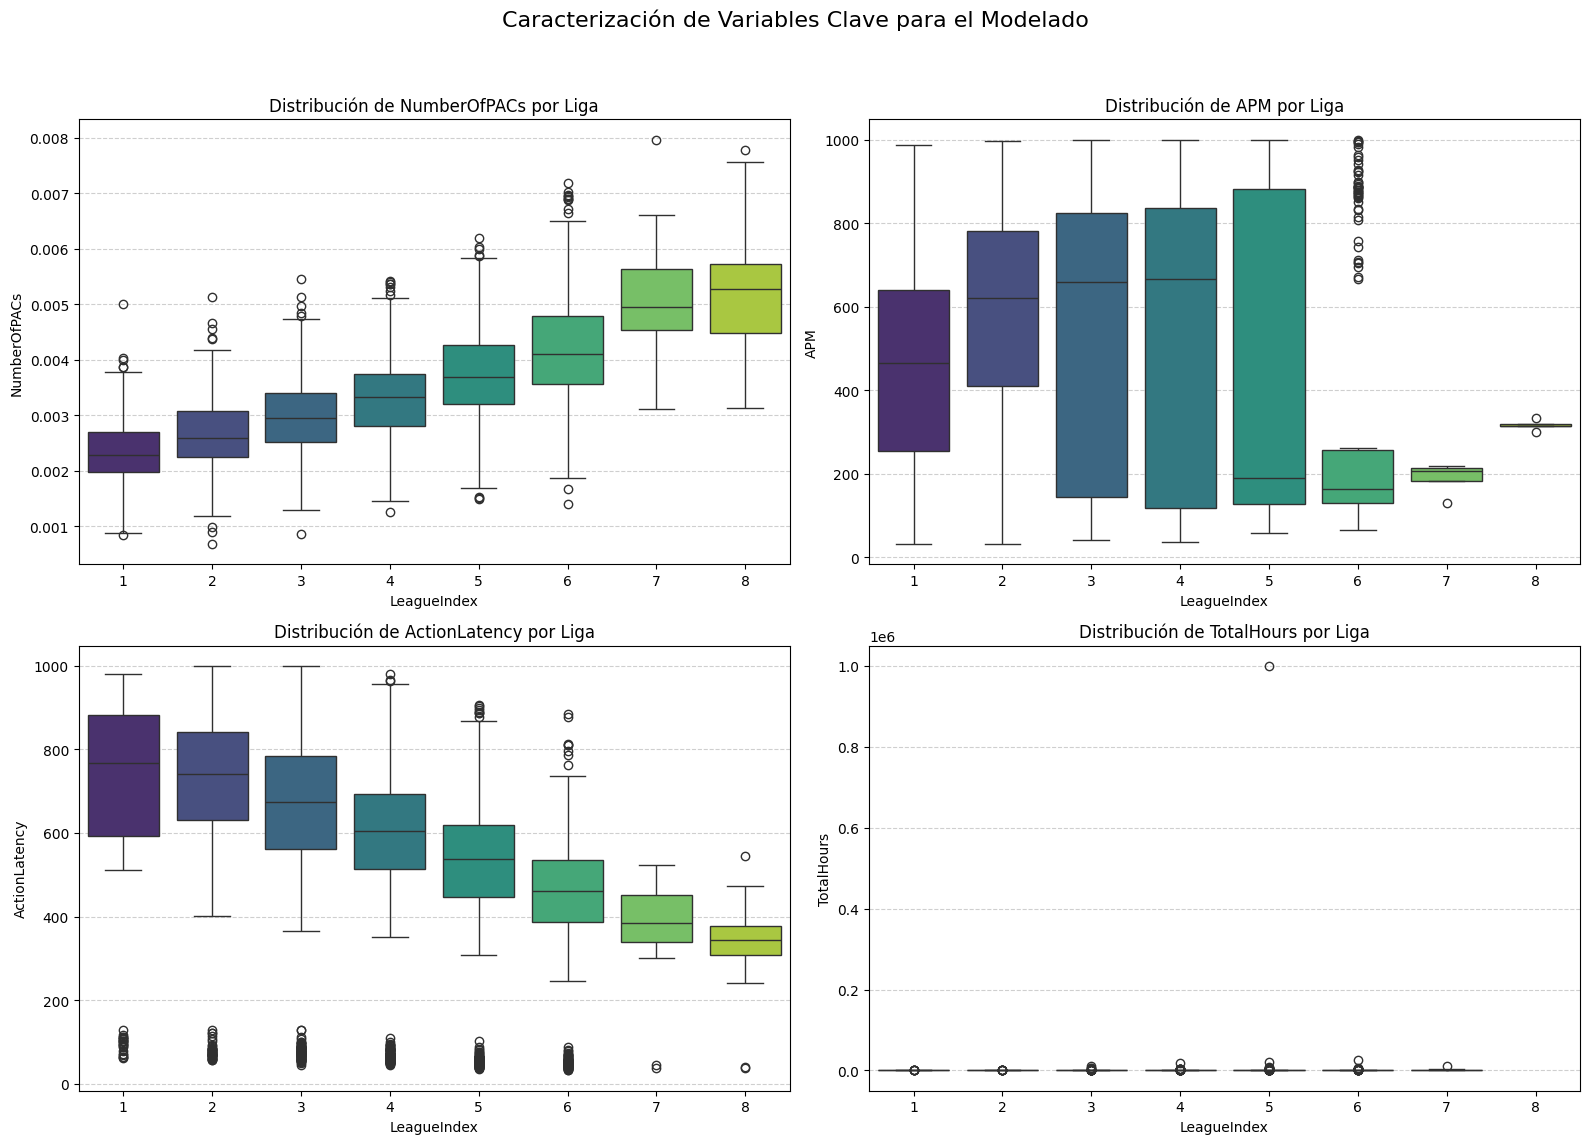

--- Estadísticas de Control para el Análisis ---
NumberOfPACs - Máximo: 0.007970642 | Nulos: 0
APM - Máximo: 999.996 | Nulos: 1549
ActionLatency - Máximo: 999.503 | Nulos: 128
TotalHours - Máximo: 1000000.0 | Nulos: 57


In [ ]:
# Definimos las variables más relevantes según la matriz de Spearman y el perfil del dataset
# NumberOfPACs (Alta corr), APM (KPI), ActionLatency (Negativa), TotalHours (Outliers)
vars_interes = ['NumberOfPACs', 'APM', 'ActionLatency', 'TotalHours']

# Casting previo para asegurar que todas sean procesables
for col in vars_interes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Configuración de la figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Caracterización de Variables Clave para el Modelado', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(vars_interes):
    sns.boxplot(ax=axes[i], x='LeagueIndex', y=col, data=df, palette='viridis')
    axes[i].set_title(f'Distribución de {col} por Liga')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Prints técnicos para apoyo posterior
print("--- Estadísticas de Control para el Análisis ---")
for col in vars_interes:
    print(f"{col} - Máximo: {df[col].max()} | Nulos: {df[col].isnull().sum()}")

**Inferencia de las anomalías**

**TotalHours:**

- **Inferencia**: Un valor de 1,000,000 es un error de registro. Representa 114 años de juego ininterrumpido.

- **Impacto**: "Secuestra" la escala del boxplot. En la imagen, todas las cajas de las ligas parecen una línea plana en el suelo porque el gráfico intenta estirarse hasta el millón. Esto oculta la verdadera variabilidad entre ligas.

**APM:**

- **Inferencia**: El máximo de ~1000 es sospechoso (el límite humano funcional suele rondar los 400-600), pero lo más grave son los 1,549 nulos.

- **Impacto**: Tienes casi un 45% de datos faltantes en una las variables más importantes. Esto sugiere que el proceso de casting (errors='coerce') convirtió muchos valores que originalmente eran caracteres no numéricos (como "?") en NaN.

**ActionLatency:**

- **Inferencia**: Un máximo de 999 ms (1 segundo de reacción) es extremadamente alto para StarCraft II. Podrían ser registros de jugadores con lag severo o inactividad momentánea.

### **8️⃣ Conclusión de la Fase 2 y Pasos a Seguir**

Inferencias sobre la Calidad de los Datos
- **TotalHours:** El valor de 1,000,000 no es un dato atípico estadístico, sino un error de captura de sistema. Representa un tiempo de juego superior a un siglo, lo que invalida cualquier cálculo de media aritmética o varianza en su estado actual.

- **APM:** El alto volumen de NaN (1,549) tras realizar el casting indica que la columna original contenía caracteres no numéricos (posiblemente "?" o errores de cadena) de forma sistemática. Esto reduce drásticamente la potencia estadística de esta variable.

- **ActionLatency:** El valor máximo cercano a 1,000 ms sugiere la presencia de latencia de red (lag) o periodos de inactividad del jugador durante la partida, más que una métrica pura de habilidad cognitiva.

**Propuesta de Solución (Fase 3: Data Preparation)**

Aunque el problema se identifica ahora, la ejecución técnica se realiza en la siguiente fase mediante las siguientes rutinas:

**1. Gestión de Outliers**

Para normalizar la escala y permitir que los modelos "vean" la diferencia entre ligas, se debe aplicar un Capping (Truncamiento).

- **Acción**: Reemplazar el valor de 1,000,000 en TotalHours por un límite lógico (ej. el percentil 99 o el máximo de la liga profesional) o eliminar ese registro específico para limpiar la distribución.

**2. Imputación de Valores Faltantes**

Debido al sesgo a la derecha identificado en los histogramas, no se debe usar la media.

- **Acción**: Implementar una imputación por la mediana agrupada por LeagueIndex. Esto significa que los nulos de un jugador de liga "Diamante" se rellenarán con la mediana de los demás jugadores de liga "Diamante", manteniendo la coherencia del perfil de habilidad.

**3. Normalización y Estabilización**

Dada la asimetría de variables como APM y NumberOfPACs:

- **Acción**: Evaluar una transformación logarítmica tras la limpieza de outliers para centrar las distribuciones y mejorar la convergencia de algoritmos lineales o de distancia.

# **🎗️ FASE 3: Preparacion de Datos**

In [ ]:
# --- PASO 1: TRANSFORMACIÓN A NUMÉRICOS ---

# Función técnica para corregir la escala de APM según el número de puntos
def corregir_apm(valor):
    str_val = str(valor)
    puntos = str_val.count('.')
    # Eliminamos todos los puntos para obtener el número puro
    numero_puro = float(str_val.replace('.', ''))

    # Si tiene 2 puntos (ej: 1.292.322), dividimos por 10.000 para obtener 129.23
    if puntos == 2:
        return numero_puro / 10000
    # Si tiene 1 punto (ej: 143.718), dividimos por 1000 para obtener 143.71
    return numero_puro / 1000

# Aplicamos la corrección específica a APM
df['APM'] = df['APM'].apply(corregir_apm)

# Columnas identificadas como 'object' en la exploración inicial
cols_object = [
    'SelectByHotkeys', 'AssignToHotkeys', 'MinimapAttacks', 'MinimapRightClicks',
    'GapBetweenPACs', 'ActionLatency', 'WorkersMade', 'UniqueUnitsMade',
    'ComplexUnitsMade', 'ComplexAbilityUsed'
]

# Conversión masiva a numeric (lo que no sea número pasará a NaN)
for col in cols_object:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- PASO 2: FILTRADO DE VALORES IMPOSIBLES (OUTLIERS) ---
# Se establecen límites basados en el dominio del negocio (StarCraft II)
df.loc[df['TotalHours'] > 100000, 'TotalHours'] = np.nan
df.loc[df['HoursPerWeek'] > 100, 'HoursPerWeek'] = np.nan
df.loc[df['APM'] > 1000, 'APM'] = np.nan

# --- PASO 3: IMPUTACIÓN GLOBAL ---
# Rellenamos todos los NaN (originales + errores de casting + outliers) con la mediana
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# Eliminamos APM por inconsistencia técnica con la lógica del negocio
df.drop(columns=['APM'], inplace=True)

# Verificamos que ya no esté
print("Variables actuales para el modelo:")
print(df.columns.tolist())

Variables actuales para el modelo:
['LeagueIndex', 'Age', 'HoursPerWeek', 'TotalHours', 'SelectByHotkeys', 'AssignToHotkeys', 'MinimapAttacks', 'MinimapRightClicks', 'NumberOfPACs', 'GapBetweenPACs', 'ActionLatency', 'ActionsInPAC', 'TotalMapExplored', 'WorkersMade', 'UniqueUnitsMade', 'ComplexUnitsMade', 'ComplexAbilityUsed', 'MaxTimeStamp']


In [ ]:
# 1. Separar características (X) y etiqueta (y)
X = df.drop(columns=['LeagueIndex'])
y = df['LeagueIndex']

# 2. División del dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"✅ Datos de prueba: {X_test.shape[0]} muestras")

✅ Datos de entrenamiento: 2716 muestras
✅ Datos de prueba: 679 muestras


In [ ]:
# Inicializar el escalador
scaler = StandardScaler()

# 1. fit_transform en entrenamiento: Calcula media/desviación y escala
X_train_scaled = scaler.fit_transform(X_train)

# 2. transform en prueba: Escala usando ÚNICAMENTE los parámetros de entrenamiento
# Esto evita la fuga de datos (data leakage)
X_test_scaled = scaler.transform(X_test)

print("✅ Escalado de variables completado.")
# Verificación estadística rápida
print(f"Media post-escalado (Train): {X_train_scaled.mean():.2f}")
print(f"Desviación estándar post-escalado (Train): {X_train_scaled.std():.2f}")

✅ Escalado de variables completado.
Media post-escalado (Train): -0.00
Desviación estándar post-escalado (Train): 1.00


In [ ]:
# 1. Inicialización del modelo con hiperparámetros base
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Entrenamiento del modelo
model.fit(X_train_scaled, y_train)

# 3. Predicción sobre el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# 4. Evaluación inicial
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Exactitud del modelo (Accuracy): {accuracy:.4f}")
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

✅ Exactitud del modelo (Accuracy): 0.4448

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           1       0.56      0.42      0.48        33
           2       0.46      0.37      0.41        70
           3       0.35      0.39      0.37       111
           4       0.39      0.42      0.40       162
           5       0.42      0.42      0.42       161
           6       0.57      0.60      0.59       124
           7       0.00      0.00      0.00         7
           8       1.00      0.82      0.90        11

    accuracy                           0.44       679
   macro avg       0.47      0.43      0.45       679
weighted avg       0.44      0.44      0.44       679



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


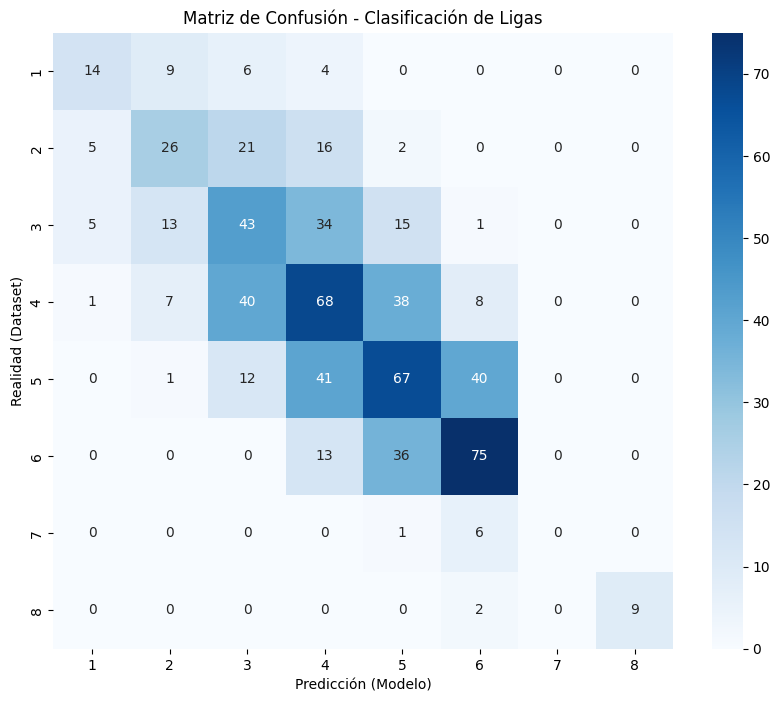

In [ ]:
# Generar la matriz
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicción (Modelo)')
plt.ylabel('Realidad (Dataset)')
plt.title('Matriz de Confusión - Clasificación de Ligas')
plt.show()

In [ ]:
# 1. Definir la función de mapeo
def agrupar_ligas(liga):
    if liga <= 2:
        return 'Bajo (1-2)'
    elif liga <= 5:
        return 'Medio (3-5)'
    else:
        return 'Alto (6-8)'

# 2. Crear la nueva variable objetivo
df['NivelHabilidad'] = df['LeagueIndex'].apply(agrupar_ligas)

# 3. Preparar nuevos conjuntos de datos
X_bin = df.drop(columns=['LeagueIndex', 'NivelHabilidad'])
y_bin = df['NivelHabilidad']

# 4. Split y Escalado
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
scaler_b = StandardScaler()
X_train_scaled_b = scaler_b.fit_transform(X_train_b)
X_test_scaled_b = scaler_b.transform(X_test_b)

# 5. Entrenar nuevo modelo
model_bin = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_bin.fit(X_train_scaled_b, y_train_b)

# 6. Evaluación
y_pred_b = model_bin.predict(X_test_scaled_b)
print(f"🚀 Nueva Exactitud (Accuracy): {accuracy_score(y_test_b, y_pred_b):.4f}")
print("\n--- Reporte de Clasificación Agrupado ---")
print(classification_report(y_test_b, y_pred_b))

🚀 Nueva Exactitud (Accuracy): 0.7408

--- Reporte de Clasificación Agrupado ---
              precision    recall  f1-score   support

  Alto (6-8)       0.71      0.48      0.57       142
  Bajo (1-2)       0.82      0.36      0.50       103
 Medio (3-5)       0.74      0.92      0.82       434

    accuracy                           0.74       679
   macro avg       0.76      0.59      0.63       679
weighted avg       0.75      0.74      0.72       679



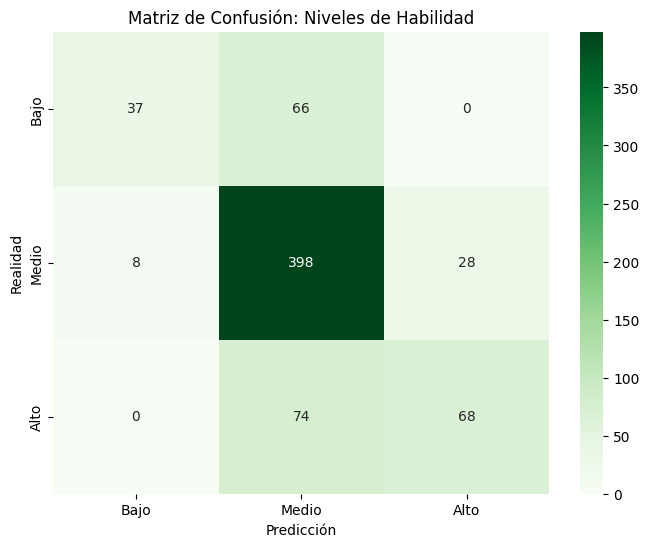

In [ ]:
# Generar matriz de confusión para el modelo de 3 niveles
cm_bin = confusion_matrix(y_test_b, y_pred_b, labels=['Bajo (1-2)', 'Medio (3-5)', 'Alto (6-8)'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.title('Matriz de Confusión: Niveles de Habilidad')
plt.show()

/tmp/ipykernel_20784/809106011.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')


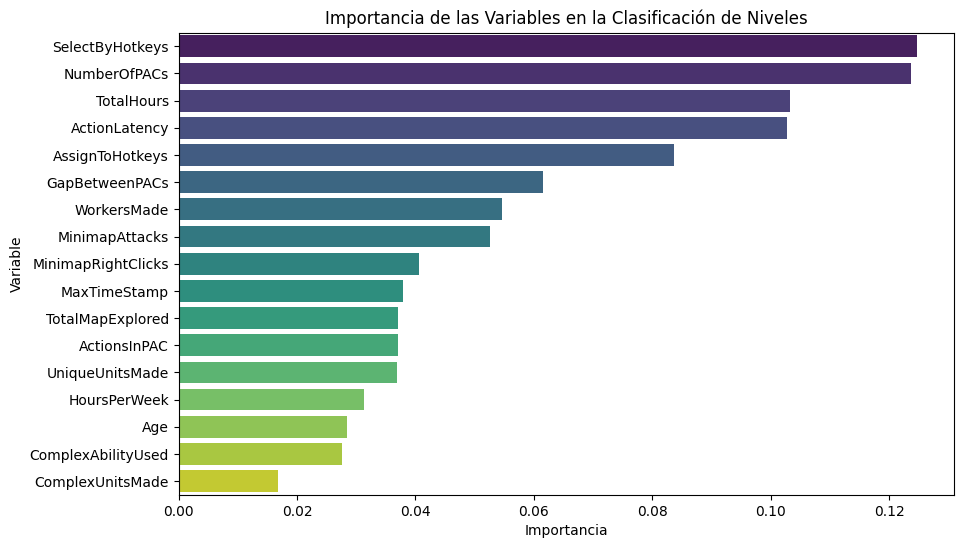

          Variable  Importancia
3  SelectByHotkeys     0.124659
7     NumberOfPACs     0.123750
2       TotalHours     0.103235
9    ActionLatency     0.102745
4  AssignToHotkeys     0.083612


In [ ]:
# Extraer importancia de las variables
importancias = model_bin.feature_importances_
nombres_features = X_bin.columns

# Crear un DataFrame para visualizarlo mejor
feature_importance_df = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables en la Clasificación de Niveles')
plt.show()

print(feature_importance_df.head(5))